# RMA Summary of Business, Cause of Loss — insured strawberry losses, 2015–2024

Spec: `CLAUDE.md` §5 (non-GEE data) and Step 5, whose county-level tabulation stayed in scope
for the exhibit's context section. This is **Figure 6**, the last outstanding deliverable.

The question it answers is not about this event's detection. It is whether the peril this
analysis studied — flood and excess moisture on strawberries in Monterey and Santa Cruz — is
**recurring or a single extreme**, which bears on whether an index for it is worth building.

Filter: state California, counties Monterey (053) and Santa Cruz (087), commodity Strawberries,
crop years 2015–2024. Indemnities by cause of loss and month.

Raw zips are downloaded by `notebooks/download_rma_col.py` into `data/raw/rma/`, with the
record layout and SHA-256 of each file in `SOURCE.md`. Column names come from the published
record layout, not from guessing a position: **Indemnity Amount is field 29.**

**CHECKPOINT:** the tabulation and Figure 6.

In [1]:
import glob
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

import common as C
from download_rma_col import COLUMNS, RAW as RMA_RAW, YEARS

STUDY_COUNTIES = ["Monterey", "Santa Cruz"]
WET = "Excess Moisture/Precipitation/Rain|Flood"

frames = []
for z in sorted(glob.glob(str(RMA_RAW / "colsom_*.zip"))):
    with zipfile.ZipFile(z) as zf:
        frames.append(pd.read_csv(zf.open(zf.namelist()[0]), sep="|", header=None,
                                  names=COLUMNS, dtype=str, encoding="latin-1"))
col = pd.concat(frames, ignore_index=True)
for c in ("state_abbrev", "county_name", "commodity_name", "cause_description", "month_name",
          "insurance_plan_abbrev"):
    col[c] = col[c].str.strip()
col["indemnity"] = pd.to_numeric(col.indemnity_amount, errors="coerce")
col["acres"] = pd.to_numeric(col.net_determined_quantity, errors="coerce")
col["year"] = col.commodity_year.astype(int)

ca = col[col.state_abbrev == "CA"]
area = ca[ca.county_name.isin(STUDY_COUNTIES)]
straw = area[area.commodity_name == "Strawberries"]

print(f"cause-of-loss rows, crop years {min(YEARS)}-{max(YEARS)}: {len(col):,} nationwide, "
      f"{len(ca):,} California, {len(area):,} in the two study counties")
print(f"STRAWBERRY rows in Monterey + Santa Cruz across all ten years: {len(straw)}")
print(f"date window: crop years {min(YEARS)}-{max(YEARS)} | dataset: USDA RMA Summary of "
      f"Business, Cause of Loss (data/raw/rma/SOURCE.md) | n units = 1320 (unchanged; this "
      f"table is county-level and does not use the units)")

cause-of-loss rows, crop years 2015-2024: 1,309,843 nationwide, 28,100 California, 363 in the two study counties
STRAWBERRY rows in Monterey + Santa Cruz across all ten years: 2
date window: crop years 2015-2024 | dataset: USDA RMA Summary of Business, Cause of Loss (data/raw/rma/SOURCE.md) | n units = 1320 (unchanged; this table is county-level and does not use the units)


## Every insured strawberry loss record in the two counties, 2015–2024

In [2]:
show = straw[["commodity_year", "county_name", "insurance_plan_abbrev", "cause_description",
              "month_name", "year_of_loss", "policies_indemnified", "acres", "indemnity"]]
print(show.to_string(index=False) if len(show) else "  (no records)")
print()
net = straw.indemnity.sum()
print(f"Net indemnity, strawberries, Monterey + Santa Cruz, 2015-2024: ${net:,.0f}")
for cty in STUDY_COUNTIES:
    n = (straw.county_name == cty).sum()
    print(f"  {cty}: {n} record(s)")
print()
print("For context, the same filter statewide:")
ca_straw = ca[ca.commodity_name == "Strawberries"]
print(ca_straw[["commodity_year", "county_name", "cause_description", "month_name",
                "policies_indemnified", "acres", "indemnity"]].to_string(index=False))
straw.to_csv(C.DERIVED / "06_rma_strawberry_col.csv", index=False)
print("\nWrote 06_rma_strawberry_col.csv")
print(f"date window: crop years {min(YEARS)}-{max(YEARS)} | dataset: USDA RMA Summary of "
      f"Business, Cause of Loss")

commodity_year county_name insurance_plan_abbrev cause_description month_name year_of_loss policies_indemnified  acres  indemnity
          2023    Monterey                 PRH-Y             Flood        MAR         2023                    2  143.5   -81927.0
          2023    Monterey                 PRH-Y             Flood        MAR         2023                    2   80.4   579486.0

Net indemnity, strawberries, Monterey + Santa Cruz, 2015-2024: $497,559
  Monterey: 2 record(s)
  Santa Cruz: 0 record(s)

For context, the same filter statewide:
commodity_year county_name                  cause_description month_name policies_indemnified   acres  indemnity
          2015     Ventura                            Insects        OCT                    1  41.100   110719.0
          2023    Monterey                              Flood        MAR                    2 143.500   -81927.0
          2023    Monterey                              Flood        MAR                    2  80.400   579

## Is the March 2023 peril recurring, or a single extreme?

Two readings are possible and they must be separated. Either the peril is rare, or the peril is
common but **uninsured**, so it never reaches this file. The all-commodity table below shows
which.

In [3]:
by_year = area.groupby("year").indemnity.sum()
wet = area[area.cause_description.str.contains(WET, case=False, na=False)]
wet_year = wet.groupby("year").indemnity.sum().reindex(by_year.index, fill_value=0)
top_cause = area.groupby("cause_description").indemnity.sum().sort_values(ascending=False)
top_crop = area.groupby("commodity_name").indemnity.sum().sort_values(ascending=False)

print("All commodities, Monterey + Santa Cruz — indemnity by year, and the wet-peril share:")
t = pd.DataFrame({"all causes": by_year, "excess moisture + flood": wet_year})
t["wet share"] = (100 * t["excess moisture + flood"] / t["all causes"]).round(1)
print(t.apply(lambda c: c.map("${:,.0f}".format) if c.name != "wet share"
              else c.map("{:.1f}%".format)).to_string())
print()
print("Top causes, all commodities, ten-year total:")
print(top_cause.head(8).map("${:,.0f}".format).to_string())
print()
print("Top commodities by indemnity, ten-year total:")
print(top_crop.head(8).map("${:,.0f}".format).to_string())
print()
wet_tot, all_tot = wet.indemnity.sum(), area.indemnity.sum()
print(f"Excess moisture and flood together: ${wet_tot:,.0f}, "
      f"{100 * wet_tot / all_tot:.1f}% of all insured loss in the two counties.")
print(f"Strawberries: ${straw.indemnity.sum():,.0f}, "
      f"{100 * straw.indemnity.sum() / all_tot:.2f}% of all insured loss.")
print()
print("READING")
print(f"  Strawberries generate {len(straw)} loss record(s) in ten years in these counties, all")
print("  of them in March 2023 and all of them coded Flood. There is no distribution to call")
print("  March 2023 an outlier within: in the federal record it is very nearly the whole of")
print("  insured strawberry loss experience here.")
print("  The county agricultural commissioner put March 2023 strawberry losses at 1,919 acres")
print(f"  and $160 million. The indemnity record for the same crop, counties and event is")
print(f"  ${straw.indemnity.sum():,.0f}. That gap is about {160e6 / max(straw.indemnity.sum(), 1):,.0f}x.")
print("  The most likely explanation is that very little strawberry acreage here carries")
print("  federal crop insurance, which is consistent with RMA exploring a new product. This")
print("  file cannot confirm that: it lists only rows where a loss was paid, so it shows")
print("  neither the insured acreage nor the participation rate.")
pd.concat([t, ], axis=1).to_csv(C.DERIVED / "06_rma_area_by_year.csv")
top_cause.to_frame("indemnity").to_csv(C.DERIVED / "06_rma_area_by_cause.csv")
print("\nWrote 06_rma_area_by_year.csv and 06_rma_area_by_cause.csv")
print(f"date window: crop years {min(YEARS)}-{max(YEARS)} | dataset: USDA RMA Summary of "
      f"Business, Cause of Loss")

All commodities, Monterey + Santa Cruz — indemnity by year, and the wet-peril share:
       all causes excess moisture + flood wet share
year                                               
2015   $7,229,108                $522,034      7.2%
2016   $1,337,885                $364,993     27.3%
2017   $1,258,386                 $36,850      2.9%
2018   $1,281,820                 $15,006      1.2%
2019   $2,860,804                $200,957      7.0%
2020  $41,566,461                 $20,088      0.0%
2021   $2,515,224                 $88,042      3.5%
2022  $10,186,371                $270,266      2.7%
2023  $14,934,187              $2,992,925     20.0%
2024  $14,519,281                $301,476      2.1%

Top causes, all commodities, ten-year total:
cause_description
Fire                                           $35,151,511
Heat                                           $19,022,475
ARPI/SCO/ECO/STAX/MP/HIP-WI/PACE Crops Only     $8,112,057
Cold Wet Weather                                $6

## Figure 6

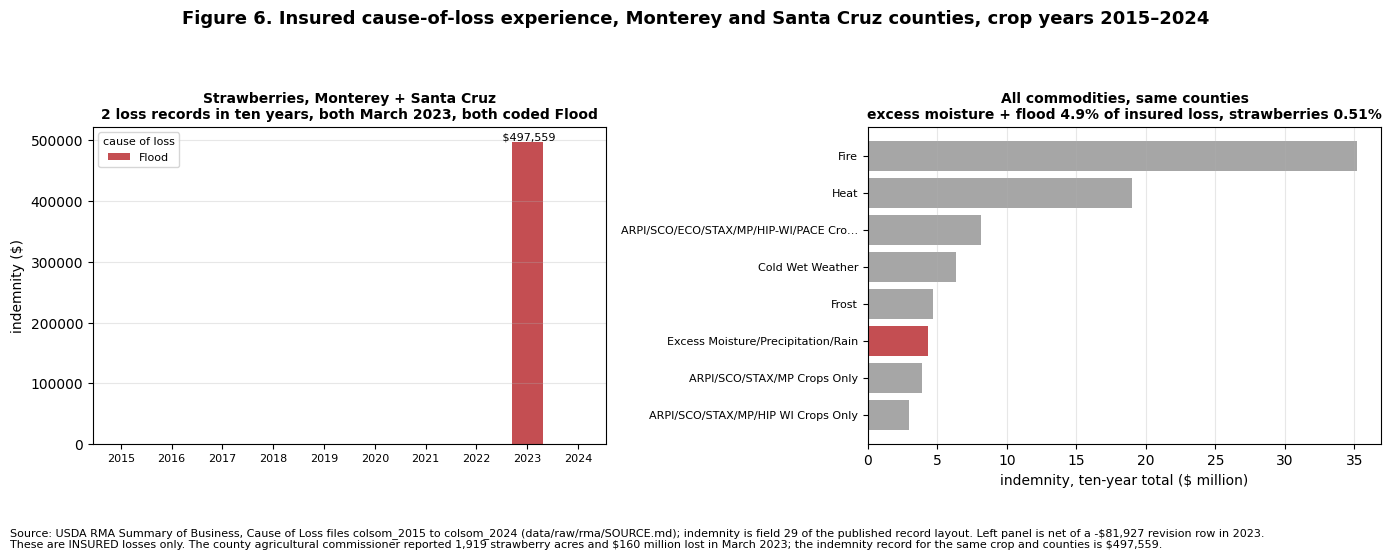

Saved fig6_rma_cause_of_loss.png
date window: crop years 2015-2024 | dataset: USDA RMA Summary of Business, Cause of Loss | n strawberry records = 2


In [4]:
plt.rcParams["mathtext.default"] = "regular"   # keep $ signs literal in labels
YEARS_AX = list(range(2015, 2025))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

ax = axes[0]
# reindex onto every crop year, so the single 2023 bar sits under 2023 and the empty
# years read as the empty years they are
g = (straw.groupby(["year", "cause_description"]).indemnity.sum().unstack(fill_value=0)
     .reindex(YEARS_AX, fill_value=0))
g.plot(kind="bar", ax=ax, color=["#C44E52"], width=0.6, legend=True)
ax.legend(fontsize=8, title="cause of loss", title_fontsize=8, loc="upper left")
for k, yr in enumerate(YEARS_AX):
    v = float(g.loc[yr].sum())
    if v:
        ax.text(k, v, f" \\${v:,.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticklabels(YEARS_AX, rotation=0, fontsize=8)
ax.set_ylabel("indemnity (\\$)")
ax.set_xlabel("")
ax.set_title("Strawberries, Monterey + Santa Cruz\n"
             f"{len(straw)} loss records in ten years, both March 2023, both coded Flood",
             fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
tc = top_cause.head(8).iloc[::-1] / 1e6
colors = ["#C44E52" if any(w in c for w in ("Excess Moisture", "Flood")) else "0.65"
          for c in tc.index]
ax.barh(range(len(tc)), tc.values, color=colors)
ax.set_yticks(range(len(tc)))
ax.set_yticklabels([c if len(c) < 38 else c[:36] + "…" for c in tc.index], fontsize=8)
ax.set_xlabel("indemnity, ten-year total (\\$ million)")
ax.set_title("All commodities, same counties\n"
             f"excess moisture + flood {100 * wet_tot / all_tot:.1f}% of insured loss, "
             f"strawberries {100 * straw.indemnity.sum() / all_tot:.2f}%",
             fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

fig.suptitle("Figure 6. Insured cause-of-loss experience, Monterey and Santa Cruz counties, "
             "crop years 2015–2024", fontsize=13, fontweight="bold")
fig.text(0.01, 0.015,
         "Source: USDA RMA Summary of Business, Cause of Loss files colsom_2015 to colsom_2024 "
         "(data/raw/rma/SOURCE.md); indemnity is field 29 of the published record layout. "
         "Left panel is net of a -\\$81,927 revision row in 2023.\n"
         "These are INSURED losses only. The county agricultural commissioner reported 1,919 "
         "strawberry acres and \\$160 million lost in March 2023; the indemnity record for "
         "the same crop and counties is \\$497,559.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.10, 1, 0.92))
FIG = C.FIGURES / "fig6_rma_cause_of_loss.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
print(f"date window: crop years {min(YEARS)}-{max(YEARS)} | dataset: USDA RMA Summary of "
      f"Business, Cause of Loss | n strawberry records = {len(straw)}")